# Resolving Power Filters (FTICR)

A brief demonstration of the resolving power filters available in CoreMS. 

## Overview

This notebook demonstrates two approaches to filtering mass spectrometry peaks based on resolving power in FT-ICR MS data:

1. **Theoretical Resolving Power Filter**: Filters peaks based on theoretical resolving power calculations derived from instrumental parameters (magnetic field strength, transient length, and apodization method).

2. **Mean Resolving Power Filter**: A statistical approach that normalizes resolving powers by m/z, then filters outliers based on mean and standard deviation.

Real FT-ICR MS data often exhibits deviations from theoretical resolving power due to various instrumental and sample factors. This tutorial compares both filtering approaches to help you choose the most appropriate method for your data quality control workflow.

## Setup and Data Import

First, we'll import the necessary CoreMS modules and Python libraries for data processing and visualization.

In [1]:
# Import key CoreMS and other functions
from corems.encapsulation.factory.parameters import MSParameters
from corems.transient.input.brukerSolarix import ReadBrukerSolarix
from corems.mass_spectrum.calc.Calibration import MzDomainCalibration
from corems.mass_spectrum.calc.MeanResolvingPowerFilter import MeanResolvingPowerFilter

In [2]:
# Import Python libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('talk')

### Define Dataset and Instrument Parameters

We'll use a Bruker FTICR-MS dataset of Suwannee River Fulvic Acid (SRFA) acquired on a 15 Tesla instrument.

In [3]:
# Define the dataset location, here use an example file: 
file_location = '../../tests/tests_data/ftms/srfa_bruker_solarix_autosampler/NEG_ESI_SRFA_Auto.d'
magnet_field = 15 # 15 Tesla dataset

### Configure Processing Parameters

We'll set up the MSParameters for optimal peak detection, including noise thresholding and peak picking settings.

In [4]:
# Define the settings for peak picking and noise thresholding to use
def set_other_params():
    MSParameters.mass_spectrum.noise_threshold_method = 'log' 
    MSParameters.mass_spectrum.noise_threshold_log_nsigma = 8
    MSParameters.ms_peak.legacy_resolving_power = False
    MSParameters.mass_spectrum.picking_point_extrapolate = 0 
    MSParameters.ms_peak.peak_min_prominence_percent = 0.001
    MSParameters.mass_spectrum.noise_min_mz = 150
    MSParameters.mass_spectrum.noise_max_mz = 800
    MSParameters.mass_spectrum.min_picking_mz = 150
    MSParameters.mass_spectrum.max_picking_mz = 800
    MSParameters.transient.number_of_zero_fills = 1

### Process the Transient and Generate Mass Spectrum

Read the Bruker transient data and process it to generate a mass spectrum with initial peak picking.

In [5]:
# Start the bruker parser
bruker_reader = ReadBrukerSolarix(file_location)

# Set the peak picking/noise threshold
set_other_params()

# Get the transient object
transient = bruker_reader.get_transient()

# Read the mass spectrum
mass_spectrum = transient.get_mass_spectrum(plot_result=False, auto_process=True)

## Initial Peak Statistics

Let's examine the total number of peaks detected before any resolving power filtering.

In [6]:
# export the masss spectrum object to a dataframe
msdf = mass_spectrum.to_dataframe()
print(f"There were {len(msdf)} peaks detected")

There were 12608 peaks detected


### Visualize Initial Peak Distribution

Plot the relationship between m/z and resolving power for all detected peaks. Point size is scaled by signal-to-noise ratio (S/N).

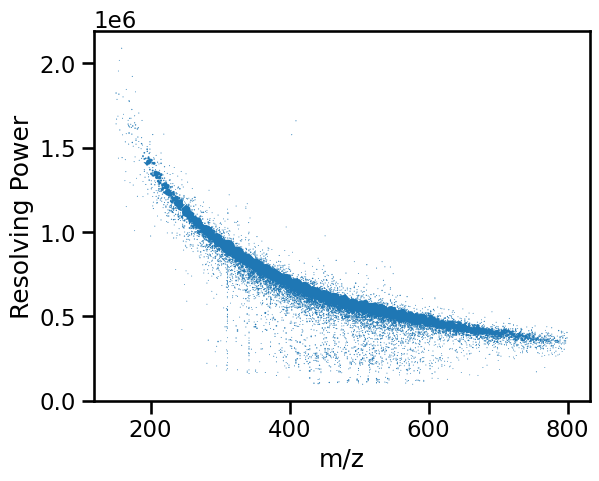

In [7]:
# Plot the masses against resolving powers for all the picked peaks
sns.scatterplot(data =msdf, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=msdf['S/N']/25)
original_data = msdf[['m/z','Resolving Power','S/N']].copy()

### Extract Instrumental Parameters

These parameters are needed to calculate the theoretical resolving power for filtering.

In [8]:
transienth_length = transient.cal_transient_time() 
print(f"The transient length was {transienth_length} seconds.")

apodization_method = transient.parameters.apodization_method
print(f"The apodization method was {apodization_method}.")

print(f"The magnet field was {magnet_field} T.")

The transient length was 2.5165824 seconds.
The apodization method was Hanning.
The magnet field was 15 T.


## Method 1: Theoretical Resolving Power Filter

Apply the theoretical resolving power filter with a 10% tolerance. This method calculates the expected resolving power based on instrumental parameters and filters peaks that fall below the threshold.

There were 7425 peaks after filtering with a tolerance of 10.0%


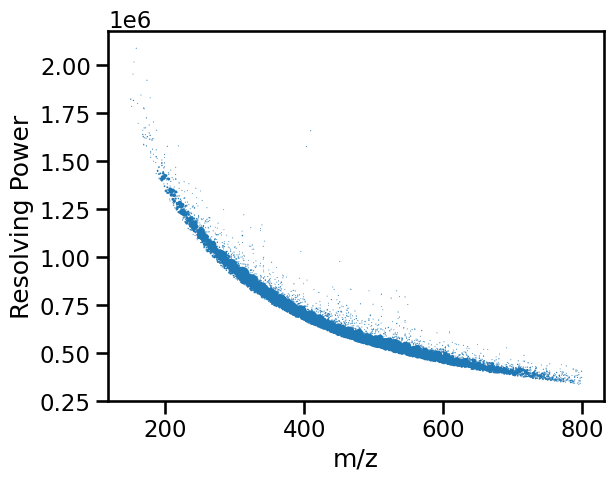

In [9]:
tolerance = 0.10

mass_spectrum.filter_by_min_resolving_power(magnet_field, transienth_length, apodization_method=apodization_method, tolerance = tolerance)

# export the masss spectrum object to a dataframe
msdf = mass_spectrum.to_dataframe()

print(f"There were {len(msdf)} peaks after filtering with a tolerance of {tolerance*100}%")

# Plot the masses against resolving powers for all the picked peaks
sns.scatterplot(data =msdf, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=msdf['S/N']/25)
theoretical_filter_data = msdf[['m/z','Resolving Power','S/N']].copy()

### Reload the Mass Spectrum

Start fresh with the original unfiltered mass spectrum for the mean filter comparison.

### Limitations of Theoretical Filtering

Evidently, the theoretical resolving power - even with a 10% tolerance - can filter out many real peaks we want to retain.

#### Two key issues exist:

1. **Apodization Calculation**: The current apodization calculation is not mathematically rigorous - improving this is on the to-do list.

2. **Real-World Imperfections**: Real data isn't perfect and often deviates from theoretical predictions due to instrumental factors, sample complexity, and signal processing effects.

## Method 2: Mean Resolving Power Filter

As an alternative, we can use a **Mean Resolving Power Filter**, which takes a statistical approach:

- Normalizes the resolving powers by m/z (for ICR data)
- Calculates the mean and standard deviation of normalized resolving powers
- Identifies and filters outliers that fall outside a specified number of standard deviations from the mean

This approach is more robust to real-world variations and typically preserves more valid peaks.

In [10]:
from corems.mass_spectrum.calc.MeanResolvingPowerFilter import MeanResolvingPowerFilter
# Read the mass spectrum
mass_spectrum = transient.get_mass_spectrum(plot_result=False, auto_process=True)

### Apply the Mean Filter

Calculate outliers using the mean resolving power filter. The visualization shows the distribution of normalized resolving powers and the threshold lines.

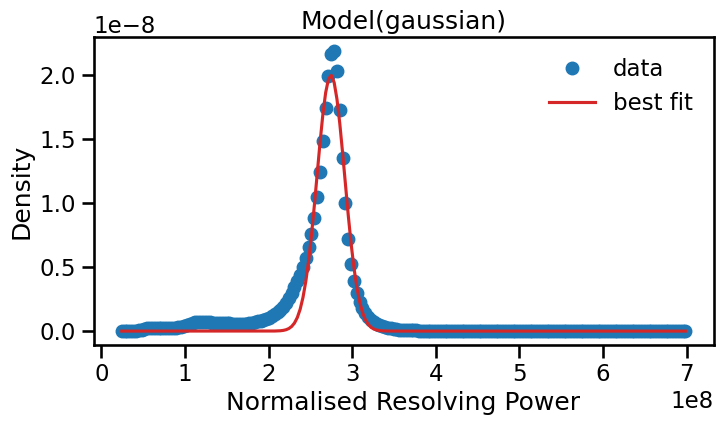

In [11]:
idx_to_remove, rps_thresh,mean_res,std_res = MeanResolvingPowerFilter(mass_spectrum, plot=True, return_rps=True).main()

Count the number of peaks identified as outliers.

In [12]:
print(f"There were {len(idx_to_remove)} peaks detected to be filtered")

There were 1369 peaks detected to be filtered


### Remove Outliers and Visualize Results

Apply the filter by removing the identified outlier peaks and visualize the cleaned peak list.

There were 11239 peaks after filtering by the mean filter and a default of 3 standard deviations


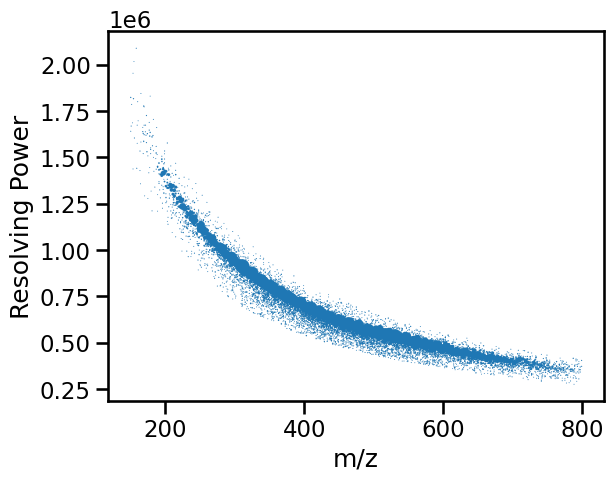

In [13]:
mass_spectrum.filter_by_index(idx_to_remove)

# export the masss spectrum object to a dataframe
msdf = mass_spectrum.to_dataframe()

print(f"There were {len(msdf)} peaks after filtering by the mean filter and a default of 3 standard deviations")

# Plot the masses against resolving powers for all the picked peaks
sns.scatterplot(data =msdf, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=msdf['S/N']/25)
mean_filter_data = msdf[['m/z','Resolving Power','S/N']].copy()

## Comparison of Filtering Methods

Compare all three datasets side-by-side: original unfiltered peaks, theoretical filter results, and mean filter results.

<Axes: xlabel='m/z', ylabel='Resolving Power'>

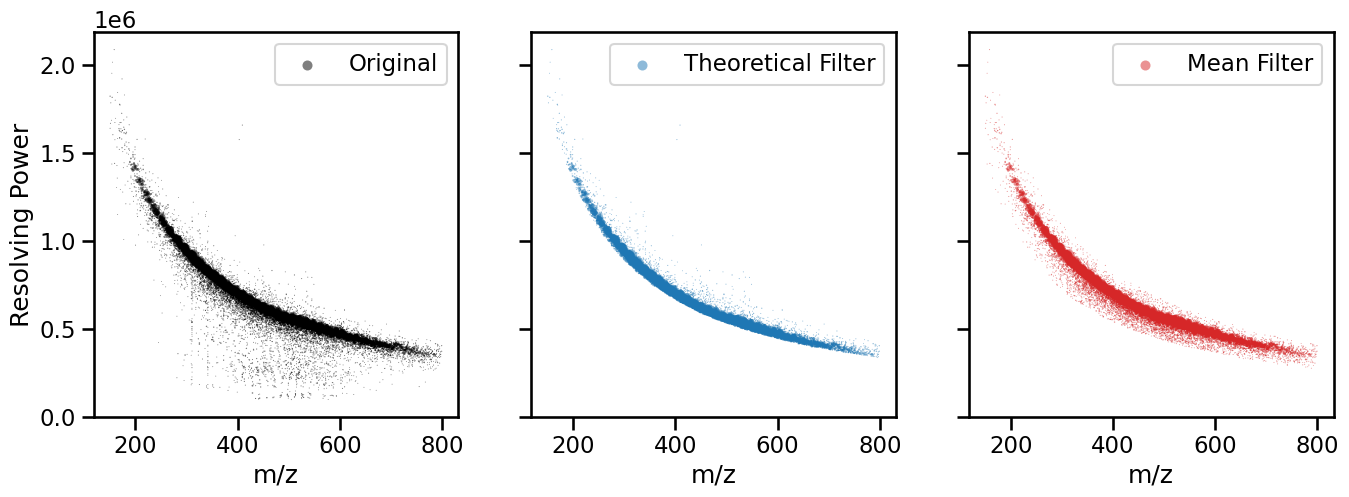

In [14]:
fig,axes = plt.subplots(figsize = (16,5), sharex=True,sharey=True, ncols=3)
sns.scatterplot(data =original_data, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=original_data['S/N']/25, alpha=0.5, c='k', label='Original', ax=axes[0])
sns.scatterplot(data =theoretical_filter_data, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=theoretical_filter_data['S/N']/25, alpha=0.5, c='tab:blue', label='Theoretical Filter', ax=axes[1])
sns.scatterplot(data =mean_filter_data, x = 'm/z', y = 'Resolving Power', edgecolor=None, s=mean_filter_data['S/N']/25, alpha=0.5, c='tab:red', label='Mean Filter', ax=axes[2])


## Conclusions

This notebook demonstrated two approaches to filtering FT-ICR MS peaks by resolving power:

**Theoretical Filter:**
- Based on instrumental parameters (magnetic field, transient length, apodization)
- Can be overly aggressive, removing valid peaks
- Useful when theoretical performance matches reality closely

**Mean Filter (Recommended):**
- Statistical approach based on actual data distribution
- More robust to real-world instrumental variations
- Preserves more valid peaks while still removing outliers
- Uses 3 standard deviations by default (configurable)

### Recommendations

For most real-world FT-ICR MS data quality control:
1. Use the **Mean Resolving Power Filter** as your primary filtering method
2. Adjust the standard deviation threshold based on your data quality requirements
3. Consider the theoretical filter only when you have well-characterized instrumental performance and need strict theoretical compliance

Both methods are available in CoreMS and can be integrated into automated processing workflows.